# Ejercicio 6: función de Lyapunov cuadrática y región de atracción

*(Traducción a Python de `ejercicio6.m`, usando `sympy`, `numpy`, `control` y `matplotlib`)*

$$\dot x_1 = x_2 + 2x_1^2 + x_1x_2, \qquad \dot x_2 = -x_1 - x_2 + x_1x_2 + 3x_2^2$$

In [1]:
import sympy as sp
import numpy as np
import control as ct
import matplotlib.pyplot as plt

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)

## Puntos singulares y linealización

In [2]:
x1, x2, a, b, s = sp.symbols('x1 x2 a b s', real=True)

f = sp.Matrix([
    x2 + 2*x1**2 + x1*x2,
    -x1 - x2 + x1*x2 + 3*x2**2
])
J = f.jacobian([x1, x2])
J

⎡4⋅x₁ + x₂     x₁ + 1    ⎤
⎢                        ⎥
⎣ x₂ - 1    x₁ + 6⋅x₂ - 1⎦

In [3]:
soluciones = sp.solve(f, [x1, x2], dict=True)
soluciones

In [4]:
for punto in soluciones:
    print('Punto de equilibrio:', punto)

    Je_sym = J.subs(punto)
    print('Je =')
    display(Je_sym)

    print('autovalores:', Je_sym.eigenvals())

    D = (s*sp.eye(2) - Je_sym).det()
    print('polinomio caracteristico:', sp.expand(D))
    print()

Punto de equilibrio: {x1: 0, x2: 0}
Je =


⎡0   1 ⎤
⎢      ⎥
⎣-1  -1⎦

autovalores: {-1/2 - sqrt(3)*I/2: 1, -1/2 + sqrt(3)*I/2: 1}
polinomio caracteristico: s**2 + s + 1

Punto de equilibrio: {x1: 1/2, x2: -1/3}
Je =


⎡5/3   3/2 ⎤
⎢          ⎥
⎣-4/3  -5/2⎦

autovalores: {-sqrt(337)/12 - 5/12: 1, -5/12 + sqrt(337)/12: 1}
polinomio caracteristico: s**2 + 5*s/6 - 13/6



Solo $(0,0)$ es estable (autovalores complejos con parte real negativa); el otro punto, $(1/2,\,-1/3)$, tiene un autovalor real positivo (silla). Así que solo tiene sentido buscar estabilidad en torno al origen.

## Función de Lyapunov cuadrática vía la ecuación de Lyapunov

Linealizamos en torno a $(0,0)$ y resolvemos la ecuación de Lyapunov $A^TP+PA=-Q$ con $Q=I$, para obtener una $P$ que sirva de base a una función de Lyapunov cuadrática. En MATLAB, `lyap(Je',Q)` resuelve exactamente $A^TP+PA=-Q$ con `A=Je`. El equivalente en `python-control` es `ct.lyap(Je.T, Q)` — recuerda (como vimos en el notebook de controlabilidad) que `control.lyap(A,Q)` resuelve $AX+XA^T=-Q$, así que para conseguir $A^TP+PA=-Q$ hay que pasarle `Je.T` como "A".

In [5]:
Je_sym = J.subs(soluciones[0])   # el punto (0,0)
Je = np.array(Je_sym.evalf(), dtype=float)
Je

array([[ 0.,  1.],
       [-1., -1.]])

In [6]:
Q = np.eye(2)
P = ct.lyap(Je.T, Q)
P

array([[1.5, 0.5],
       [0.5, 1. ]])

La función de Lyapunov es entonces $V=x^TPx$.

In [7]:
Psym = sp.Matrix(P)
xv = sp.Matrix([x1, x2])

V = (xv.T * Psym * xv)[0, 0]
V = sp.nsimplify(sp.simplify(V), rational=True)
V

Para aplicarla al sistema no lineal, calculamos su derivada de Lie usando $f$ completa (no la linealizada),

In [8]:
grV = sp.Matrix([sp.diff(V, x1), sp.diff(V, x2)])
dotV = sp.simplify((grV.T * f)[0, 0])
dotV

Fíjate en que la parte cuadrática de $\dot V$ es exactamente $-x_1^2-x_2^2$ (como cabía esperar, ya que resolvimos $A^TP+PA=-Q$ con $Q=I$); los términos cúbicos restantes son la aportación de la no linealidad del sistema original, y son los que limitan hasta dónde $\dot V$ se mantiene negativa — de ahí la necesidad de acotar una región de atracción, que es lo que exploramos a continuación.

## Visualización: paraboloide de $V$, plano límite y curvas de nivel

Dibujamos el paraboloide definido por $V$ (que, sustituyendo los valores numéricos de $P$, resulta $\frac{3}{2}x_1^2+x_1x_2+x_2^2$).

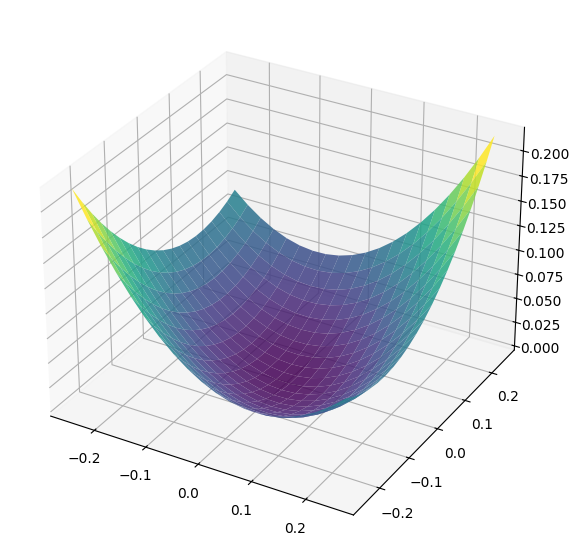

In [9]:
x1p = np.linspace(-0.25, 0.25, 20)
x2p = x1p.copy()
x1mp, x2mp = np.meshgrid(x1p, x2p)
zm_parab = 3*(x1mp**2)/2 + x1mp*x2mp + x2mp**2

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x1mp, x2mp, zm_parab, cmap='viridis', alpha=0.85)

Añadimos el plano $x_1+x_2=1/6$: este plano marca el límite a partir del cual la derivada de Lyapunov deja de ser negativa. Tenemos que imponer la condición de que los puntos de inicio no superen el valor de $V$ correspondiente al punto más bajo del corte de la función de Lyapunov con este plano vertical. De este modo, obtenemos una cuenca de atracción para el punto fijo $(0,0)$ asociada a la función de Lyapunov empleada.

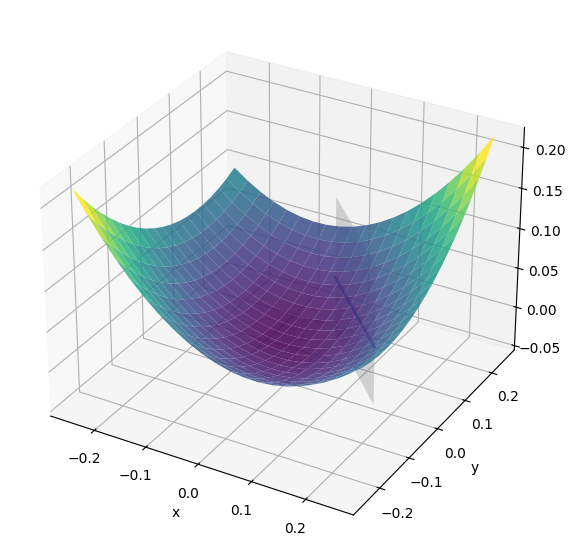

In [10]:
x = np.linspace(0, 1/6, 5)
y = 1/6 - x
xm = np.tile(x, (8, 1))
ym = np.tile(y, (8, 1))
z = np.array([-0.05, -0.025, 0, 0.025, 0.05, 0.075, 0.1, 0.125])
zm_plano = np.tile(z, (5, 1)).T

ax.plot_surface(xm, ym, zm_plano, color='gray', alpha=0.3)

ax.set_xlabel('x')
ax.set_ylabel('y')

ax.plot(x, y, 5/216*np.ones_like(x), color='tab:blue', linewidth=2)   # linea al nivel critico

fig

Pintamos la curva famosa: la intersección de $V$ con el nivel crítico $z=5/216$, proyectada al plano $(x_1,x_2)$.

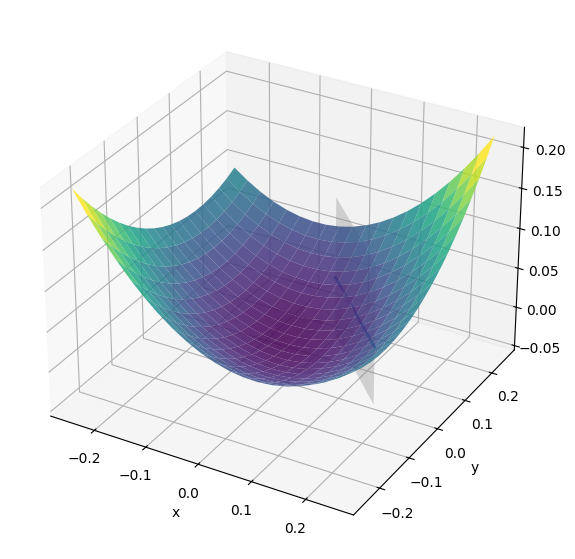

In [11]:
x1cu = np.linspace(-np.sqrt(4/216), np.sqrt(4/216), 200)
x2cu1 = (-x1cu + np.sqrt(np.maximum(20/216 - 5*(x1cu**2), 0))) / 2   # mitad
x2cu2 = (-x1cu - np.sqrt(np.maximum(20/216 - 5*(x1cu**2), 0))) / 2   # otra mitad

ax.plot(x1cu, x2cu1, 5/216*np.ones_like(x1cu), color='white', linewidth=1)
ax.plot(x1cu, x2cu2, 5/216*np.ones_like(x1cu), color='white', linewidth=1)

fig

Y ya puestos, el círculo que definiría la condición de Lyapunov a la misma altura (la cuenca de atracción "segura" más conservadora).

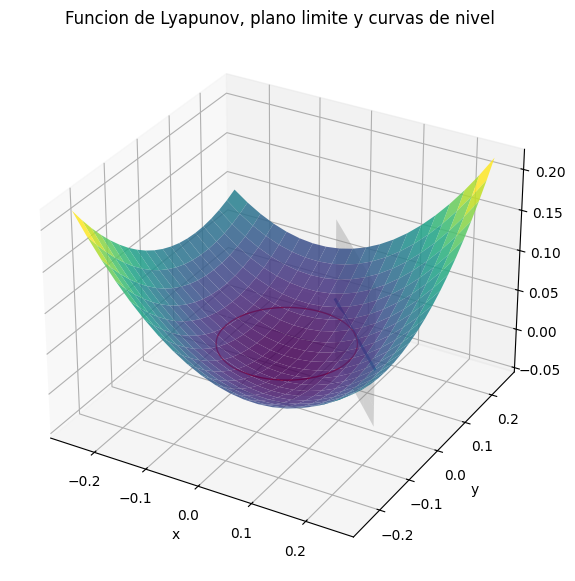

In [12]:
x1c = np.linspace(-np.sqrt(2)/12, np.sqrt(2)/12, 200)
x2p_c = np.sqrt(np.maximum(1/72 - x1c**2, 0))
x2m_c = -np.sqrt(np.maximum(1/72 - x1c**2, 0))

ax.plot(x1c, x2p_c, 5/216*np.ones_like(x1c), color='red', linewidth=1)
ax.plot(x1c, x2m_c, 5/216*np.ones_like(x1c), color='red', linewidth=1)

ax.set_title('Funcion de Lyapunov, plano limite y curvas de nivel')
fig

La curva roja (círculo) es la estimación más conservadora, pero más sencilla de caracterizar, de la región de atracción del origen; la curva blanca (más ajustada al plano límite real) es una estimación algo más precisa, pero de forma menos simple.